In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
student_name = "Mark Aldred"  # Replace with your actual name
student_id = "TUPM-25-1253"  # Replace with your actual ID 
 
id_num = int(student_id[-3:]) 
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) 
% 256:02x}" 
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) 
% 256:02x}"

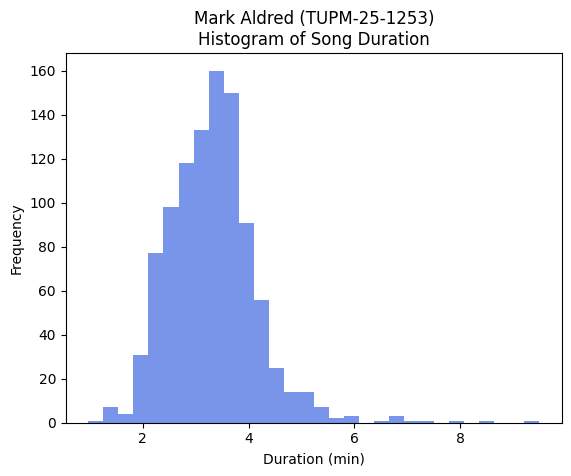

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your personal details
student_name = "Mark Aldred"
student_id = "TUPM-25-1253"
color1 = 'royalblue'

# 2. Load the data (make sure the CSV is in the same folder)
df = pd.read_csv("spotify_top_1000_tracks.csv")

# 3. Create the missing column again
if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000

# --- NOW your plotting code will work ---
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Frequency') 
plt.show()

Available columns: ['track_name', 'artist', 'album', 'release_date', 'popularity', 'spotify_url', 'id', 'duration_min']


C:\Users\Mark Aldred\AppData\Local\Temp\ipykernel_4200\3470311039.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


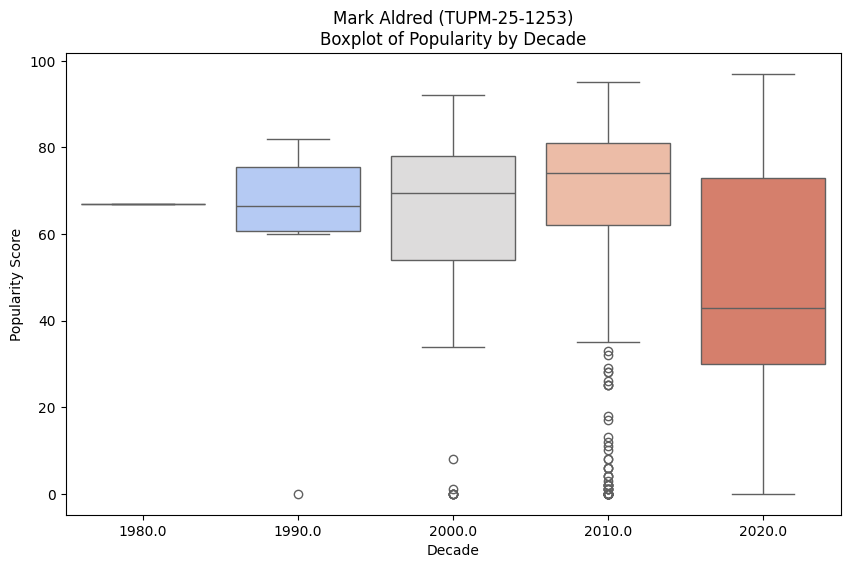

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Debug: Let's see what columns actually exist
print("Available columns:", df.columns.tolist())

# 2. Fix: Re-create the 'year' column if it's missing
if 'year' not in df.columns:
    if 'release_date' in df.columns:
        df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
        df['year'] = df['release_date'].dt.year
    elif 'release_year' in df.columns: # Sometimes the CSV uses this name
        df['year'] = df['release_year']
    else:
        # Fallback: if we can't find a year, let's look for any column with 'year' in it
        year_cols = [c for c in df.columns if 'year' in c.lower()]
        if year_cols:
            df['year'] = df[year_cols[0]]

# 3. Drop rows where year is NaN so the math doesn't break
df = df.dropna(subset=['year'])

# 4. Calculation for Decade
df['decade'] = (df['year'] // 10) * 10

# 5. Plotting (Fixed the f-string syntax error too)
plt.figure(figsize=(10, 6))
student_name = "Mark Aldred"
student_id = "TUPM-25-1253"

sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.xlabel("Decade")
plt.ylabel("Popularity Score")
plt.show()

C:\Users\Mark Aldred\AppData\Local\Temp\ipykernel_4200\887992834.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


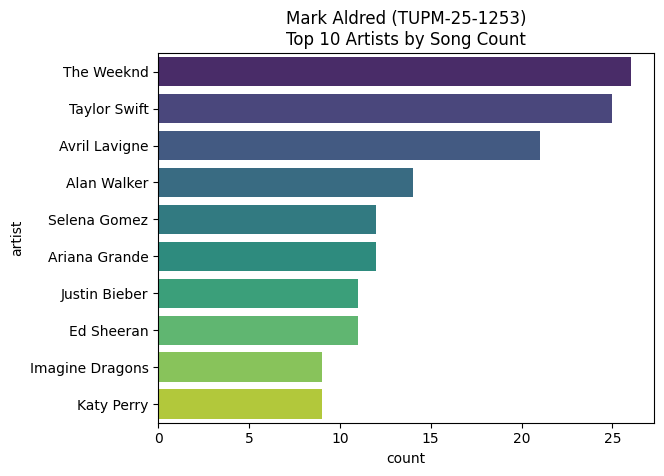

In [7]:
sns.countplot(y='artist', data=df, 
order=df['artist'].value_counts().head(10).index, palette='viridis') 
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count") 
plt.show()

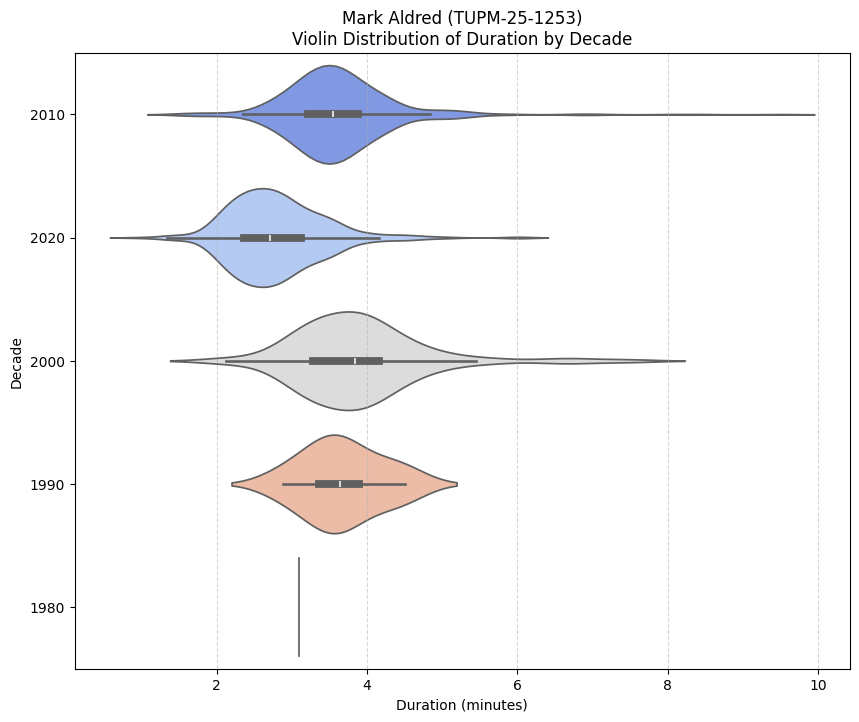

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure decade is treated as a category/string so it colors correctly
df['decade'] = df['decade'].astype(int).astype(str)

plt.figure(figsize=(10, 8))

# Fix: x is the number, y is the group
sns.violinplot(
    data=df, 
    x='duration_min', 
    y='decade', 
    palette='coolwarm', 
    hue='decade',      # Added hue to fix a common warning
    legend=False, 
    fill=True          # Makes it look more like a "Ridge" plot
)

plt.title(f"{student_name} ({student_id})\nViolin Distribution of Duration by Decade")
plt.xlabel("Duration (minutes)")
plt.ylabel("Decade")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

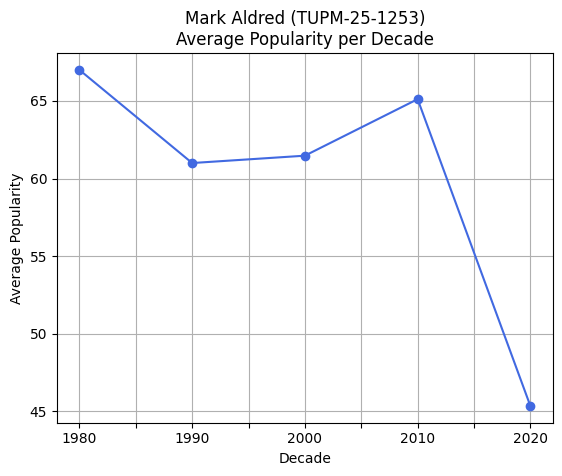

In [9]:
avg_pop = df.groupby('decade')['popularity'].mean() 
avg_pop.plot(kind='line', color=color1, marker='o') 
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade") 
plt.xlabel('Decade') 
plt.ylabel('Average Popularity') 
plt.grid(True) 
plt.show()

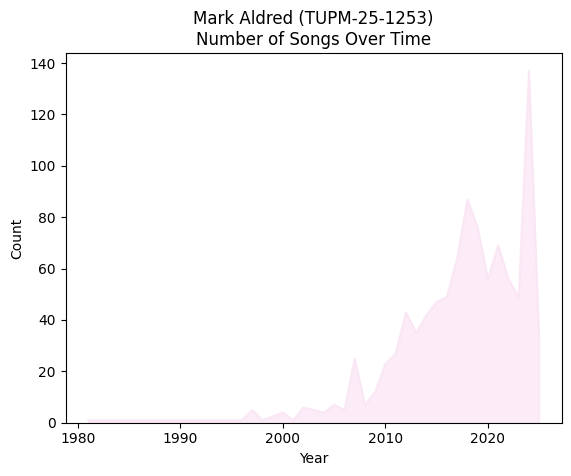

In [10]:
df['release_year'] = pd.to_datetime(df['release_date'], 
errors='coerce').dt.year 
count_by_year = df['release_year'].value_counts().sort_index() 
count_by_year.plot(kind='area', color=color2, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time") 
plt.xlabel('Year') 
plt.ylabel('Count') 
plt.show()

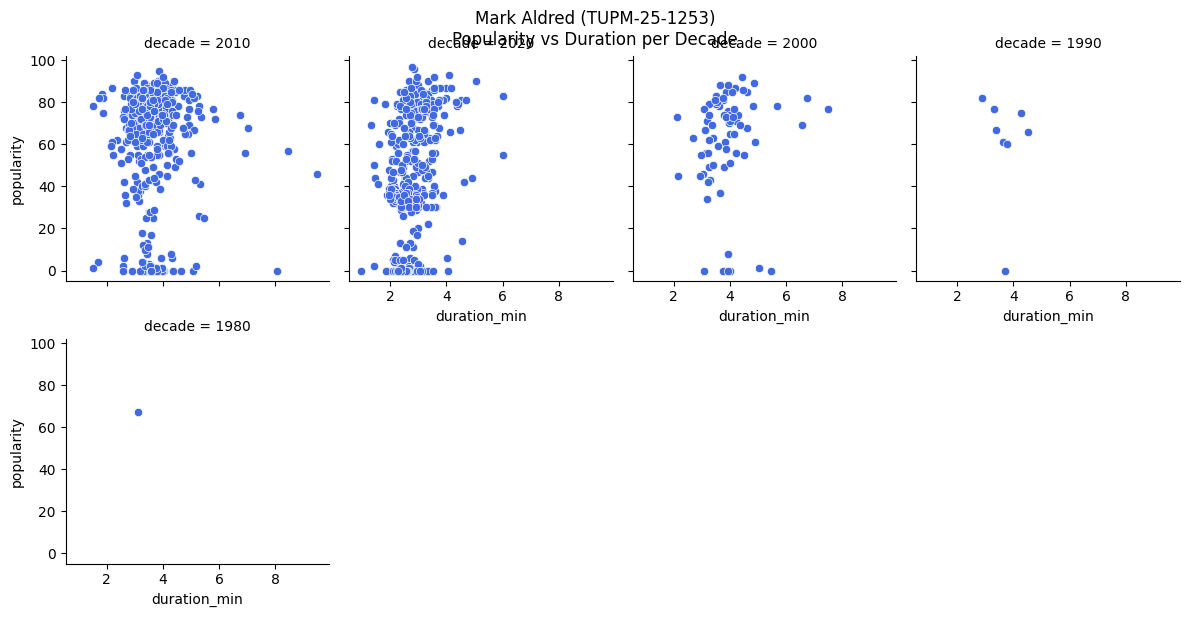

In [11]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3) 
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1) 
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02) 
plt.show()

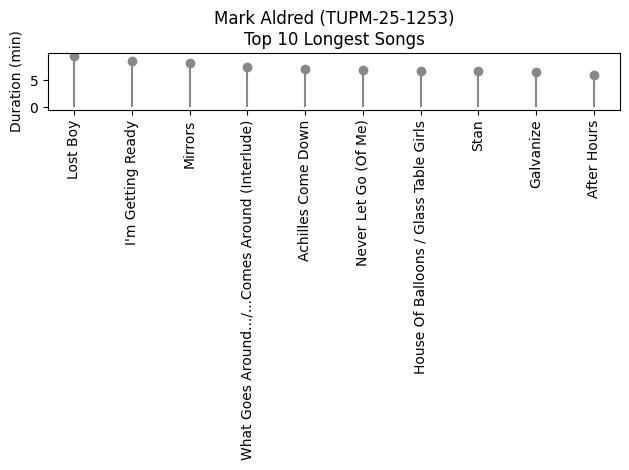

In [12]:
longest = df.nlargest(10, 'duration_min') 
plt.stem(longest['track_name'], longest['duration_min'], 
linefmt='#888888', markerfmt='o', basefmt=" ") 
plt.xticks(rotation=90) 
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs") 
plt.ylabel('Duration (min)') 
plt.tight_layout() 
plt.show() 

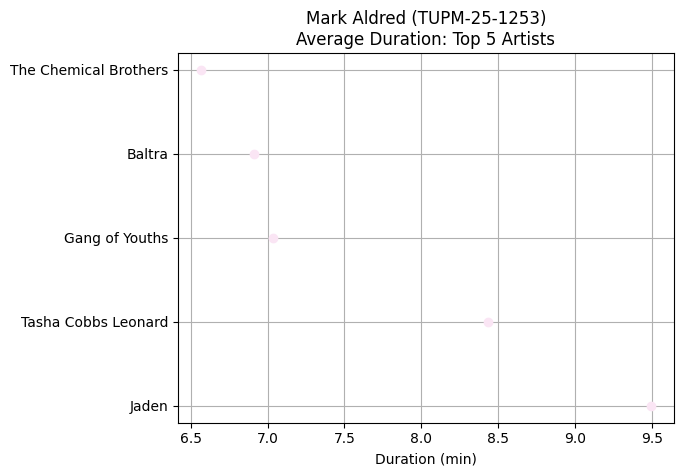

In [13]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show() 

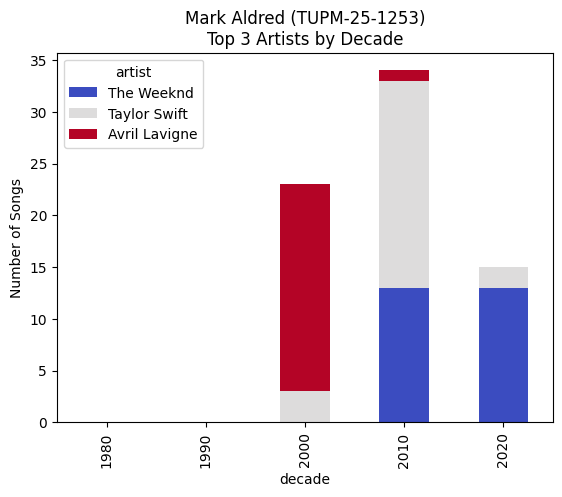

In [14]:
crosstab = pd.crosstab(df['decade'], df['artist']) 
top3 = df['artist'].value_counts().head(3).index 
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm') 
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade") 
plt.ylabel('Number of Songs') 
plt.show()

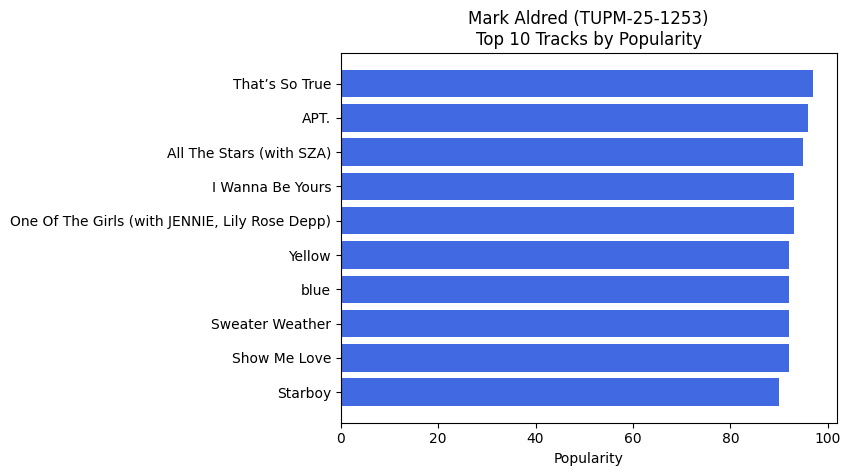

In [15]:
top_tracks = df.nlargest(10, 'popularity') 
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1) 
plt.xlabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity") 
plt.gca().invert_yaxis() 
plt.show() 

C:\Users\Mark Aldred\AppData\Local\Temp\ipykernel_4200\1182823657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\Mark Aldred\AppData\Local\Temp\ipykernel_4200\1182823657.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


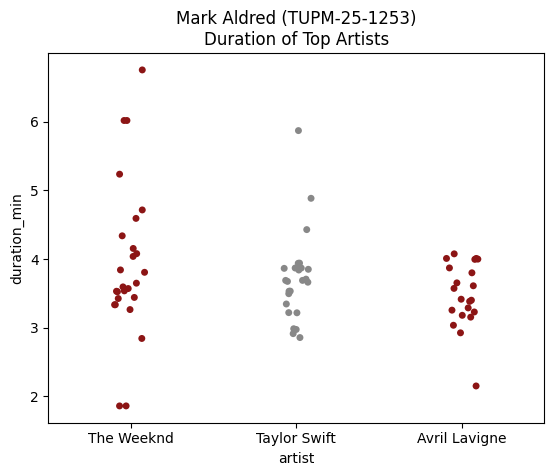

In [16]:
top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', 
y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show()

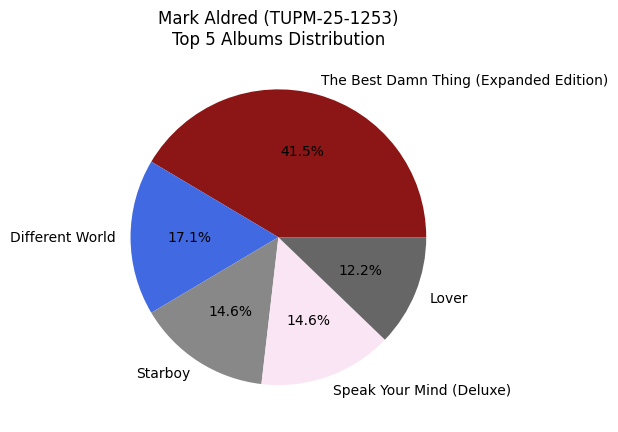

In [17]:
top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show() 

In [18]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


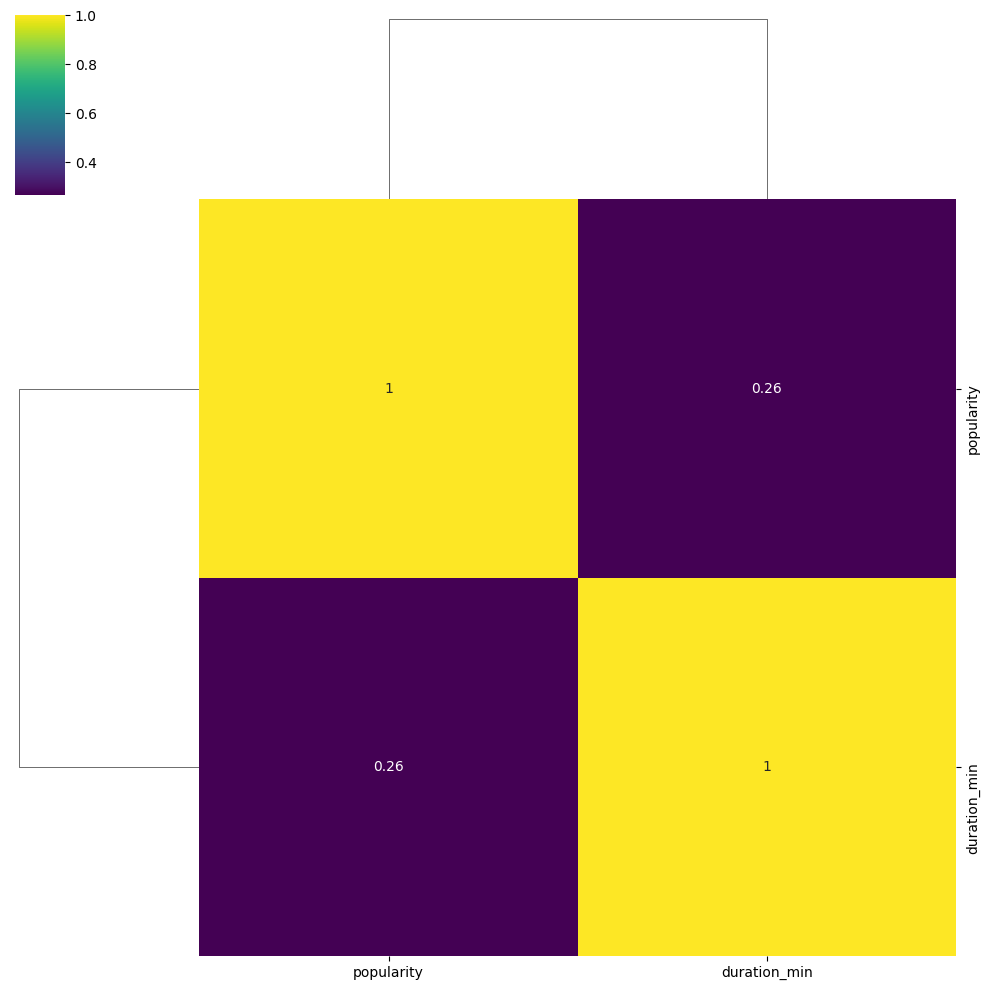

In [19]:
# Add more numerical columns if your CSV has them!
numerical_cols = ['popularity', 'duration_min', 'danceability', 'energy', 'tempo']
# Filter only the columns that actually exist in your df
available_cols = [c for c in numerical_cols if c in df.columns]

df_numeric = df[available_cols].dropna()
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis')

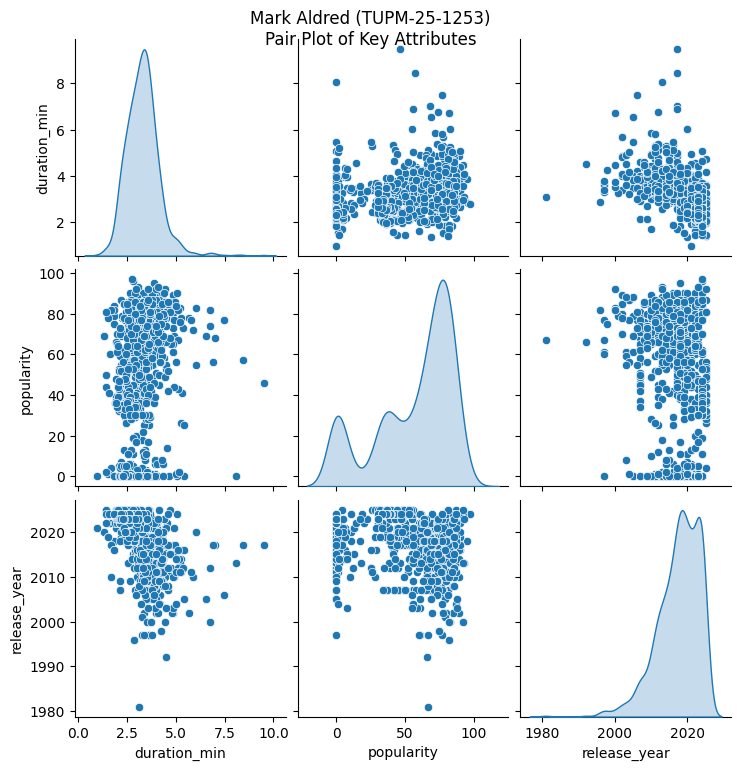

In [21]:
sns.pairplot(df[['duration_min', 'popularity', 'release_year']], diag_kind='kde') 
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02) 
plt.show() 

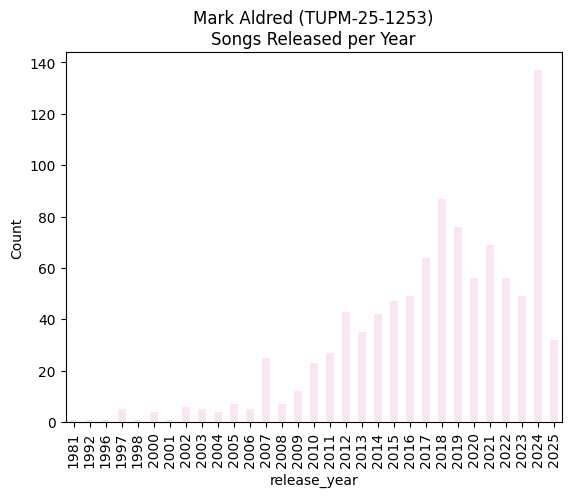

In [22]:
df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2) 
plt.title(f"{student_name} ({student_id})\nSongs Released per Year") 
plt.ylabel('Count') 
plt.show()

C:\Users\Mark Aldred\AppData\Local\Temp\ipykernel_4200\3875629107.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


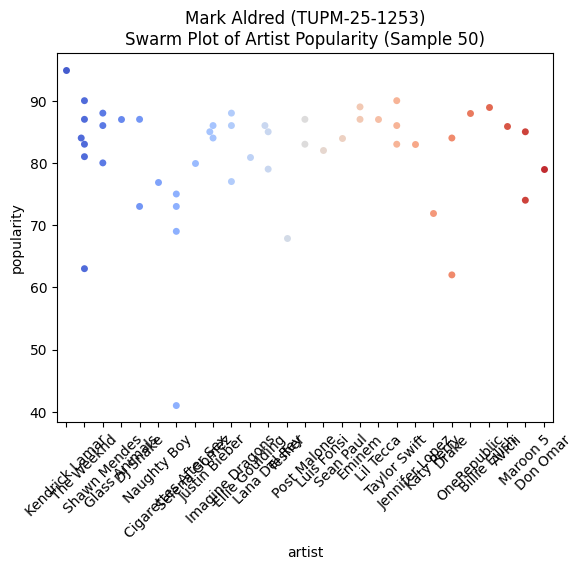

In [23]:
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)") 
plt.xticks(rotation=45) 
plt.show() 

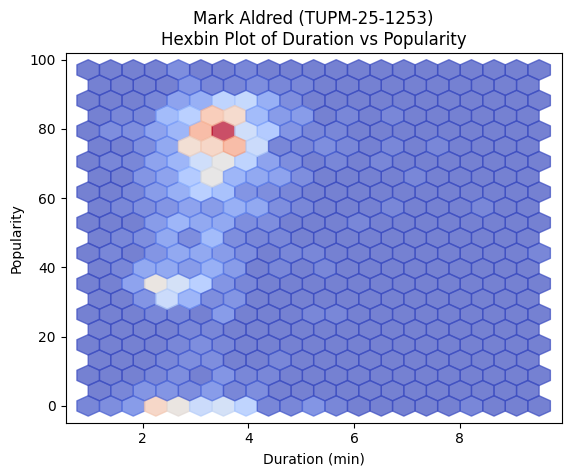

In [24]:
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7) 
plt.xlabel('Duration (min)') 
plt.ylabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity") 
plt.show()

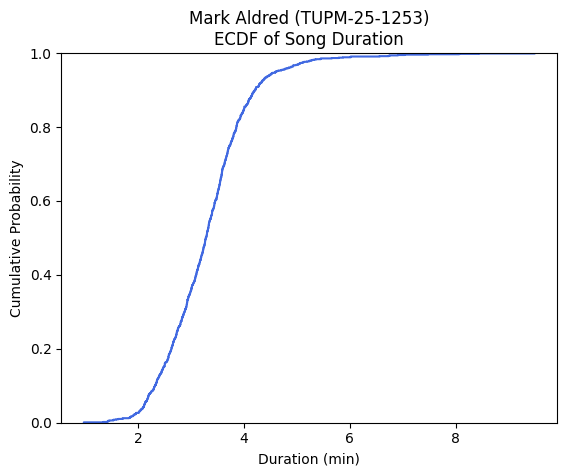

In [25]:
sns.ecdfplot(data=df, x='duration_min', color=color1) 
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Cumulative Probability') 
plt.show()

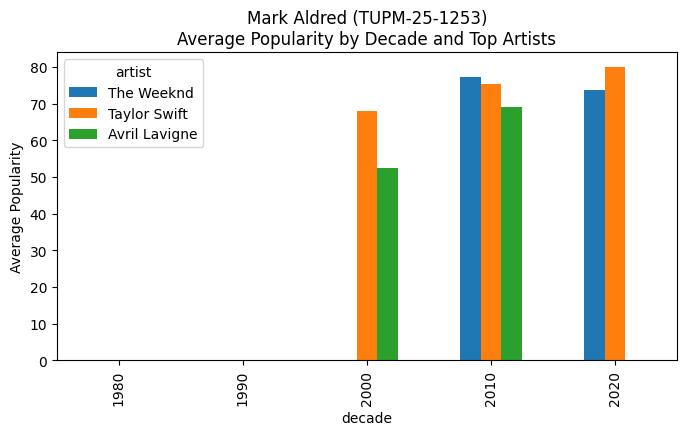

In [26]:
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0) 
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4)) 
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists") 
plt.ylabel('Average Popularity') 
plt.show() 